<a href="https://colab.research.google.com/github/Swastika-Roy/Python-concepts/blob/main/DuplicateHandling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Upload file in Colab OR use uploaded path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load dataset
# The previous error occurred because you were trying to load a .ipynb file (Jupyter Notebook) with pd.read_csv.
# pd.read_csv expects a CSV file. Please replace 'path/to/your/data.csv' with the actual path to your CSV data file.
# For example, if your data is in a file named 'your_data.csv' in the Colab content directory, it would be '/content/your_data.csv'.
df = pd.read_csv('/content/02_duplicates.csv') # Replace 'path/to/your/data.csv' with your actual CSV file path

print('Dataset shape:', df.shape)
print("="*80)
print("Dimension:", df.ndim)
print("Size:", df.size)
print("Column Names:", df.columns.tolist())
print("Index:", df.index.tolist())
print("Data Types:\n", df.dtypes)
print("="*80)
df.info()
df.describe()

Dataset shape: (27, 8)
Dimension: 2
Size: 216
Column Names: ['Order_ID', 'Customer_ID', 'Customer_Name', 'Product', 'Quantity', 'Price', 'Order_Date', 'Status']
Index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26]
Data Types:
 Order_ID           int64
Customer_ID       object
Customer_Name     object
Product           object
Quantity           int64
Price            float64
Order_Date        object
Status            object
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       27 non-null     int64  
 1   Customer_ID    27 non-null     object 
 2   Customer_Name  27 non-null     object 
 3   Product        27 non-null     object 
 4   Quantity       27 non-null     int64  
 5   Price          27 non-null     float64
 6   Order_Date     27 non-null     object 
 7   Sta

,Order_ID,Quantity,Price
count,27.000000,27.000000,27.000000
mean,1010.148148,1.777778,312.222222
std,6.608291,1.219500,408.318158
min,1001.000000,1.000000,10.000000
25%,1004.500000,1.000000,37.500000
50%,1009.000000,1.000000,120.000000
75%,1015.500000,2.000000,365.000000
max,1022.000000,5.000000,1200.000000


In [2]:
#Check for complete row duplicates
duplicates = df.duplicated()
print(f"Total Duplicate rows : {duplicates.sum()}")

Total Duplicate rows : 5


In [3]:
#view duplicate rows
duplicate_rows = df[df.duplicated(keep=False)]
print("\\n All duplicate Rows: ")
print(duplicate_rows)

\n All duplicate Rows: 
    Order_ID Customer_ID   Customer_Name    Product  Quantity   Price  \
0       1001        C001      John Smith     Laptop         1  1200.0   
1       1002        C002   Sarah Johnson      Mouse         2    25.0   
3       1004        C004      Emma Brown    Monitor         1   350.0   
5       1006        C006     Lisa Garcia     Webcam         1   120.0   
7       1008        C008  Jennifer Davis  USB Cable         5    10.0   
10      1002        C002   Sarah Johnson      Mouse         2    25.0   
13      1004        C004      Emma Brown    Monitor         1   350.0   
23      1008        C008  Jennifer Davis  USB Cable         5    10.0   
25      1001        C001      John Smith     Laptop         1  1200.0   
26      1006        C006     Lisa Garcia     Webcam         1   120.0   

    Order_Date     Status  
0   2023-01-15  Completed  
1   2023-01-16  Completed  
3   2023-01-18    Shipped  
5   2023-01-20    Pending  
7   2023-01-22  Completed  
10  

In [4]:
#DUPLICATES BASED ON ORDER_ID ONLY
dup_order_id = df[df.duplicated(subset=['Order_ID'],keep=False)]
print('Duplicates by Order_ID:')
dup_order_id.sort_values('Order_ID')

Duplicates by Order_ID:


,Order_ID,Customer_ID,Customer_Name,Product,Quantity,Price,Order_Date,Status
0,1001,C001,John Smith,Laptop,1,1200.0,2023-01-15,Completed
25,1001,C001,John Smith,Laptop,1,1200.0,2023-01-15,Completed
10,1002,C002,Sarah Johnson,Mouse,2,25.0,2023-01-16,Completed
1,1002,C002,Sarah Johnson,Mouse,2,25.0,2023-01-16,Completed
13,1004,C004,Emma Brown,Monitor,1,350.0,2023-01-18,Shipped
3,1004,C004,Emma Brown,Monitor,1,350.0,2023-01-18,Shipped
26,1006,C006,Lisa Garcia,Webcam,1,120.0,2023-01-20,Pending
5,1006,C006,Lisa Garcia,Webcam,1,120.0,2023-01-20,Pending
23,1008,C008,Jennifer Davis,USB Cable,5,10.0,2023-01-22,Completed
7,1008,C008,Jennifer Davis,USB Cable,5,10.0,2023-01-22,Completed


In [5]:
#Duplicates based on mutiple columns
dup_multi = df[df.duplicated(subset=['Customer_ID','Product'],keep=False)]
print("\\nDuplicates by Customer_ID and Product:")
dup_multi

\nDuplicates by Customer_ID and Product:


,Order_ID,Customer_ID,Customer_Name,Product,Quantity,Price,Order_Date,Status
0,1001,C001,John Smith,Laptop,1,1200.0,2023-01-15,Completed
1,1002,C002,Sarah Johnson,Mouse,2,25.0,2023-01-16,Completed
3,1004,C004,Emma Brown,Monitor,1,350.0,2023-01-18,Shipped
5,1006,C006,Lisa Garcia,Webcam,1,120.0,2023-01-20,Pending
7,1008,C008,Jennifer Davis,USB Cable,5,10.0,2023-01-22,Completed
10,1002,C002,Sarah Johnson,Mouse,2,25.0,2023-01-16,Completed
13,1004,C004,Emma Brown,Monitor,1,350.0,2023-01-18,Shipped
22,1021,C001,John Smith,Laptop,1,1200.0,2023-02-04,Completed
23,1008,C008,Jennifer Davis,USB Cable,5,10.0,2023-01-22,Completed
25,1001,C001,John Smith,Laptop,1,1200.0,2023-01-15,Completed


In [6]:
# Comprehensive duplicate analysis
def duplicate_analysis(df):
    print("="*60)
    print("DUPLICATE ANALYSIS REPORT")
    print("="*60)

    # Complete duplicates
    complete_dups = df.duplicated().sum()
    print(f"\\n1. Complete Row Duplicates: {complete_dups}")

    # Duplicates by each column
    print("\\n2. Duplicates by Column:")
    for col in df.columns:
        dup_count = df.duplicated(subset=[col]).sum()
        dup_pct = (dup_count / len(df)) * 100
        print(f"   {col}: {dup_count} ({dup_pct:.2f}%)")

    # Value counts for duplicated Order_IDs
    print("\\n3. Most Repeated Order_IDs:")
    order_counts = df['Order_ID'].value_counts()
    repeated = order_counts[order_counts > 1]
    print(repeated)

    return complete_dups

duplicate_analysis(df)

DUPLICATE ANALYSIS REPORT
\n1. Complete Row Duplicates: 5
\n2. Duplicates by Column:
   Order_ID: 5 (18.52%)
   Customer_ID: 6 (22.22%)
   Customer_Name: 6 (22.22%)
   Product: 7 (25.93%)
   Quantity: 22 (81.48%)
   Price: 7 (25.93%)
   Order_Date: 5 (18.52%)
   Status: 24 (88.89%)
\n3. Most Repeated Order_IDs:
Order_ID
1001    2
1002    2
1004    2
1006    2
1008    2
Name: count, dtype: int64


np.int64(5)

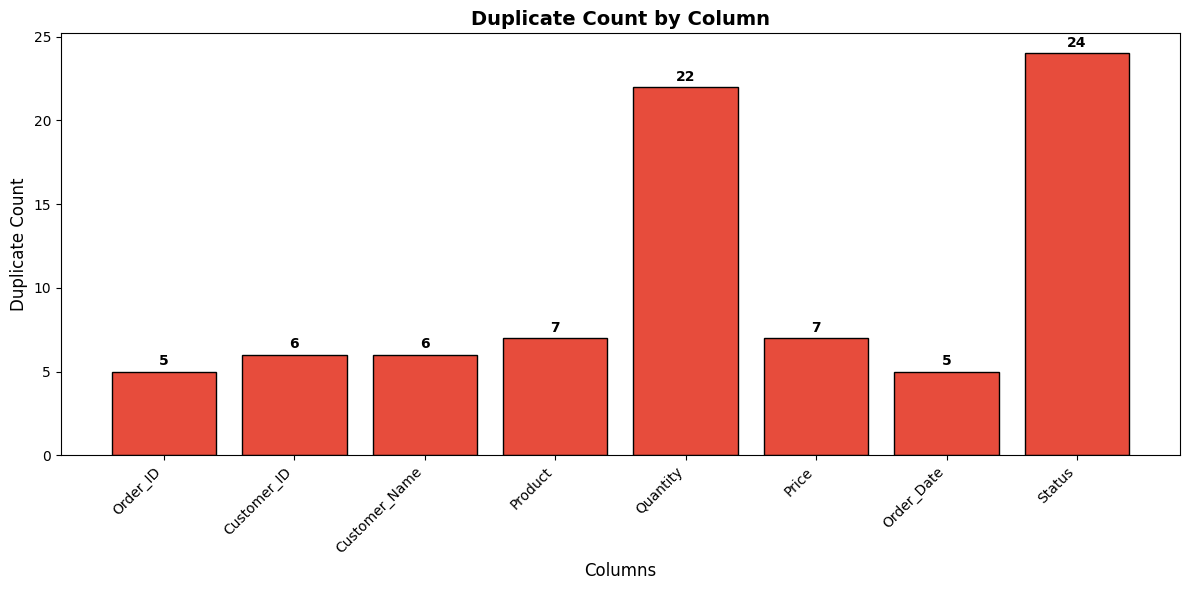

In [7]:
plt.figure(figsize=(12, 6))

# Count duplicates per column
dup_counts = {}
for col in df.columns:
    dup_counts[col] = df.duplicated(subset=[col]).sum()

colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in dup_counts.values()]

bars = plt.bar(dup_counts.keys(), dup_counts.values(), color=colors, edgecolor='black')
plt.xlabel('Columns', fontsize=12)
plt.ylabel('Duplicate Count', fontsize=12)
plt.title('Duplicate Count by Column', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')

# Add value labels
for bar, val in zip(bars, dup_counts.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             str(val), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('duplicate_count_by_column.png', dpi=300, bbox_inches='tight')
plt.show()

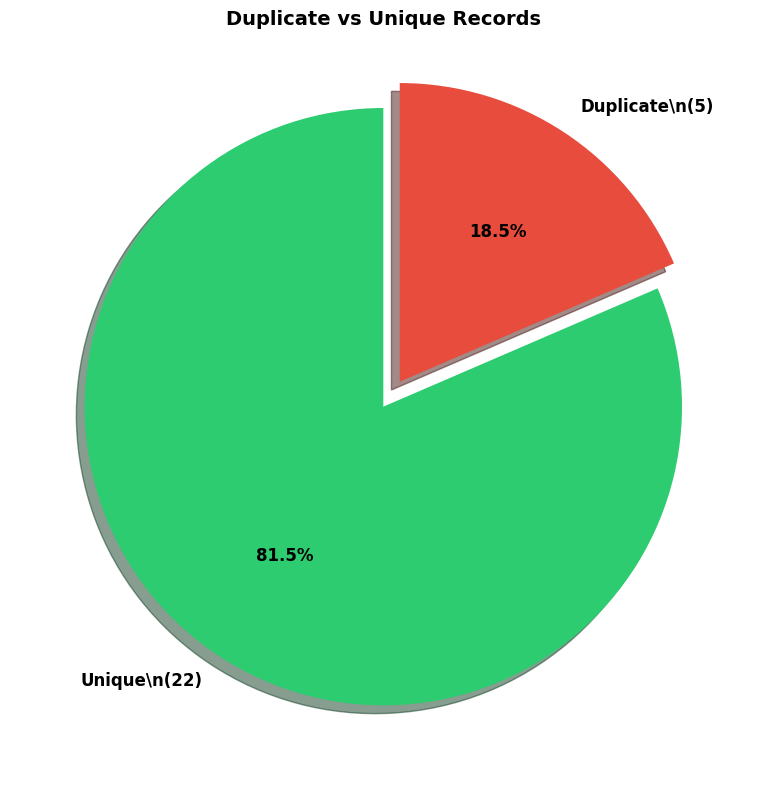

In [10]:
plt.figure(figsize=(8, 8))

duplicate_count = df.duplicated().sum()
unique_count = len(df) - duplicate_count

sizes = [unique_count, duplicate_count]
labels = [f'Unique\\n({unique_count})', f'Duplicate\\n({duplicate_count})']
colors = ['#2ecc71', '#e74c3c']
explode = (0, 0.1)

plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.1f%%', shadow = True,
        startangle=90,
        textprops={'fontsize': 12, 'fontweight': 'bold'})

plt.title('Duplicate vs Unique Records', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('duplicate_pie_chart.png', dpi=300, bbox_inches='tight')
plt.show()

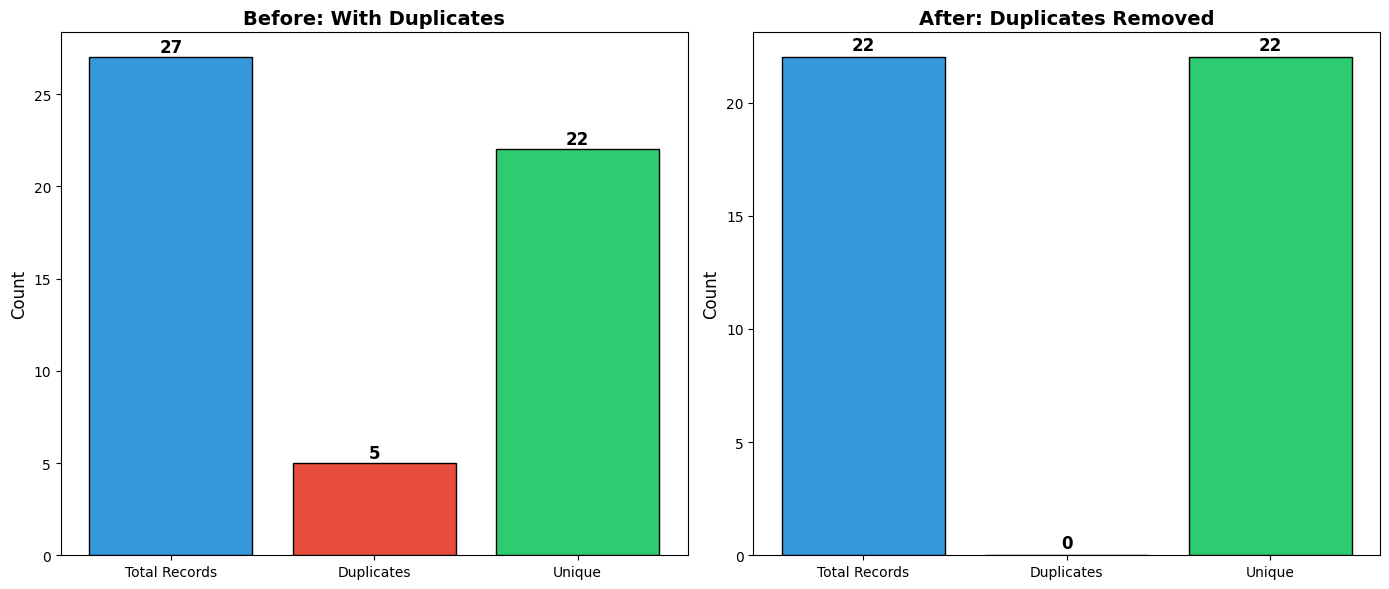

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Before: With duplicates
axes[0].bar(['Total Records', 'Duplicates', 'Unique'],
            [len(df), df.duplicated().sum(), len(df) - df.duplicated().sum()],
            color=['#3498db', '#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Before: With Duplicates', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=12)

# Add values on bars
for i, v in enumerate([len(df), df.duplicated().sum(), len(df) - df.duplicated().sum()]):
    axes[0].text(i, v + 0.3, str(v), ha='center', fontweight='bold', fontsize=12)

# After: Without duplicates
df_clean = df.drop_duplicates()
axes[1].bar(['Total Records', 'Duplicates', 'Unique'],
            [len(df_clean), 0, len(df_clean)],
            color=['#3498db', '#e74c3c', '#2ecc71'], edgecolor='black')
axes[1].set_title('After: Duplicates Removed', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count', fontsize=12)

# Add values on bars
for i, v in enumerate([len(df_clean), 0, len(df_clean)]):
    axes[1].text(i, v + 0.3, str(v), ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('before_after_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [13]:
df_first = df.drop_duplicates(keep='first')
print(f"Original : {len(df)} -> After(keep first):{len(df_first)}")
df_first

Original : 27 -> After(keep first):22


,Order_ID,Customer_ID,Customer_Name,Product,Quantity,Price,Order_Date,Status
0,1001,C001,John Smith,Laptop,1,1200.0,2023-01-15,Completed
1,1002,C002,Sarah Johnson,Mouse,2,25.0,2023-01-16,Completed
2,1003,C003,Mike Williams,Keyboard,1,75.0,2023-01-17,Pending
3,1004,C004,Emma Brown,Monitor,1,350.0,2023-01-18,Shipped
4,1005,C005,David Jones,Headphones,3,80.0,2023-01-19,Completed
5,1006,C006,Lisa Garcia,Webcam,1,120.0,2023-01-20,Pending
6,1007,C007,Robert Miller,Speaker,2,150.0,2023-01-21,Shipped
7,1008,C008,Jennifer Davis,USB Cable,5,10.0,2023-01-22,Completed
8,1009,C009,William Rodriguez,HDMI Cable,2,15.0,2023-01-23,Pending
9,1010,C010,Mary Martinez,Printer,1,250.0,2023-01-24,Shipped


In [14]:
df_last = df.drop_duplicates(keep='last')
print(f"Original : {len(df)} -> After(keep last):{len(df_last)}")
df_last

Original : 27 -> After(keep last):22


,Order_ID,Customer_ID,Customer_Name,Product,Quantity,Price,Order_Date,Status
2,1003,C003,Mike Williams,Keyboard,1,75.0,2023-01-17,Pending
4,1005,C005,David Jones,Headphones,3,80.0,2023-01-19,Completed
6,1007,C007,Robert Miller,Speaker,2,150.0,2023-01-21,Shipped
8,1009,C009,William Rodriguez,HDMI Cable,2,15.0,2023-01-23,Pending
9,1010,C010,Mary Martinez,Printer,1,250.0,2023-01-24,Shipped
10,1002,C002,Sarah Johnson,Mouse,2,25.0,2023-01-16,Completed
11,1011,C011,James Hernandez,Scanner,1,180.0,2023-01-25,Completed
12,1012,C012,Patricia Lopez,Microphone,1,95.0,2023-01-26,Pending
13,1004,C004,Emma Brown,Monitor,1,350.0,2023-01-18,Shipped
14,1013,C013,Richard Gonzalez,Router,1,110.0,2023-01-27,Completed


In [16]:
df_none = df.drop_duplicates(keep=False)
print(f"Original : {len(df)} -> After(keep none):{len(df_none)}")
df_none

Original : 27 -> After(keep none):17


,Order_ID,Customer_ID,Customer_Name,Product,Quantity,Price,Order_Date,Status
2,1003,C003,Mike Williams,Keyboard,1,75.0,2023-01-17,Pending
4,1005,C005,David Jones,Headphones,3,80.0,2023-01-19,Completed
6,1007,C007,Robert Miller,Speaker,2,150.0,2023-01-21,Shipped
8,1009,C009,William Rodriguez,HDMI Cable,2,15.0,2023-01-23,Pending
9,1010,C010,Mary Martinez,Printer,1,250.0,2023-01-24,Shipped
11,1011,C011,James Hernandez,Scanner,1,180.0,2023-01-25,Completed
12,1012,C012,Patricia Lopez,Microphone,1,95.0,2023-01-26,Pending
14,1013,C013,Richard Gonzalez,Router,1,110.0,2023-01-27,Completed
15,1014,C014,Linda Wilson,Switch,2,90.0,2023-01-28,Pending
16,1015,C015,Thomas Anderson,Tablet,1,450.0,2023-01-29,Shipped


In [20]:
df_order_first = df.drop_duplicates(subset=['Order_ID'], keep='first')
print(f"Original: {len(df)} -> After (by order id) : {len(df_order_first)}")
df_order_first


Original: 27 -> After (by order id) : 22


,Order_ID,Customer_ID,Customer_Name,Product,Quantity,Price,Order_Date,Status
0,1001,C001,John Smith,Laptop,1,1200.0,2023-01-15,Completed
1,1002,C002,Sarah Johnson,Mouse,2,25.0,2023-01-16,Completed
2,1003,C003,Mike Williams,Keyboard,1,75.0,2023-01-17,Pending
3,1004,C004,Emma Brown,Monitor,1,350.0,2023-01-18,Shipped
4,1005,C005,David Jones,Headphones,3,80.0,2023-01-19,Completed
5,1006,C006,Lisa Garcia,Webcam,1,120.0,2023-01-20,Pending
6,1007,C007,Robert Miller,Speaker,2,150.0,2023-01-21,Shipped
7,1008,C008,Jennifer Davis,USB Cable,5,10.0,2023-01-22,Completed
8,1009,C009,William Rodriguez,HDMI Cable,2,15.0,2023-01-23,Pending
9,1010,C010,Mary Martinez,Printer,1,250.0,2023-01-24,Shipped


In [21]:
df_multi = df.drop_duplicates(subset=['Order_ID', 'Product', 'Order_Date'], keep='first')
print(f"Original: {len(df)} -> After (multi col) : {len(df_multi)}")
df_multi

Original: 27 -> After (multi col) : 22


,Order_ID,Customer_ID,Customer_Name,Product,Quantity,Price,Order_Date,Status
0,1001,C001,John Smith,Laptop,1,1200.0,2023-01-15,Completed
1,1002,C002,Sarah Johnson,Mouse,2,25.0,2023-01-16,Completed
2,1003,C003,Mike Williams,Keyboard,1,75.0,2023-01-17,Pending
3,1004,C004,Emma Brown,Monitor,1,350.0,2023-01-18,Shipped
4,1005,C005,David Jones,Headphones,3,80.0,2023-01-19,Completed
5,1006,C006,Lisa Garcia,Webcam,1,120.0,2023-01-20,Pending
6,1007,C007,Robert Miller,Speaker,2,150.0,2023-01-21,Shipped
7,1008,C008,Jennifer Davis,USB Cable,5,10.0,2023-01-22,Completed
8,1009,C009,William Rodriguez,HDMI Cable,2,15.0,2023-01-23,Pending
9,1010,C010,Mary Martinez,Printer,1,250.0,2023-01-24,Shipped
